In [35]:
!pip install -q imbalanced-learn joblib

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

import warnings
warnings.filterwarnings("ignore")

In [37]:
import pandas as pd

df = pd.read_csv("titanic.csv", sep="\t")

# Convert column names to lowercase
df.columns = df.columns.str.lower()

print("Dataset loaded from titanic.csv")
print("Shape:", df.shape)

display(df.head())

Dataset loaded from titanic.csv
Shape: (156, 12)


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
print("Survival class counts:")
print(df["survived"].value_counts())

print("\nSurvival class percentages:")
print(df["survived"].value_counts(normalize=True).mul(100).round(2))

Survival class counts:
survived
0    102
1     54
Name: count, dtype: int64

Survival class percentages:
survived
0    65.38
1    34.62
Name: proportion, dtype: float64


In [39]:
print(df.columns.tolist())

['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


In [40]:
target = "survived"

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target:
survived


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data shape: (124, 7)
Testing data shape: (32, 7)

Training target distribution:
survived
0    0.653
1    0.347
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.656
1    0.344
Name: proportion, dtype: float64


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [43]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [44]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

print("Three model pipelines created successfully.")

Three model pipelines created successfully.


In [46]:
logistic_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [47]:
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_tree = tree_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [49]:
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob)
    }

logistic_metrics = calculate_metrics(
    y_test, y_pred_logistic, y_prob_logistic
)

tree_metrics = calculate_metrics(
    y_test, y_pred_tree, y_prob_tree
)

rf_metrics = calculate_metrics(
    y_test, y_pred_rf, y_prob_rf
)

print("Logistic Regression:", logistic_metrics)
print("\nDecision Tree:", tree_metrics)
print("\nRandom Forest:", rf_metrics)

Logistic Regression: {'Accuracy': 0.8125, 'Precision': 0.7272727272727273, 'Recall': 0.7272727272727273, 'F1': 0.7272727272727273, 'AUC': np.float64(0.8744588744588745)}

Decision Tree: {'Accuracy': 0.8125, 'Precision': 0.7777777777777778, 'Recall': 0.6363636363636364, 'F1': 0.7, 'AUC': np.float64(0.8506493506493507)}

Random Forest: {'Accuracy': 0.875, 'Precision': 0.8181818181818182, 'Recall': 0.8181818181818182, 'F1': 0.8181818181818182, 'AUC': np.float64(0.8484848484848484)}


In [50]:
comparison_df = pd.DataFrame(
    [logistic_metrics, tree_metrics, rf_metrics],
    index=["Logistic Regression", "Decision Tree", "Random Forest"]
)

display(comparison_df.round(3))

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.812,0.727,0.727,0.727,0.874
Decision Tree,0.812,0.778,0.636,0.700,0.851
Random Forest,0.875,0.818,0.818,0.818,0.848


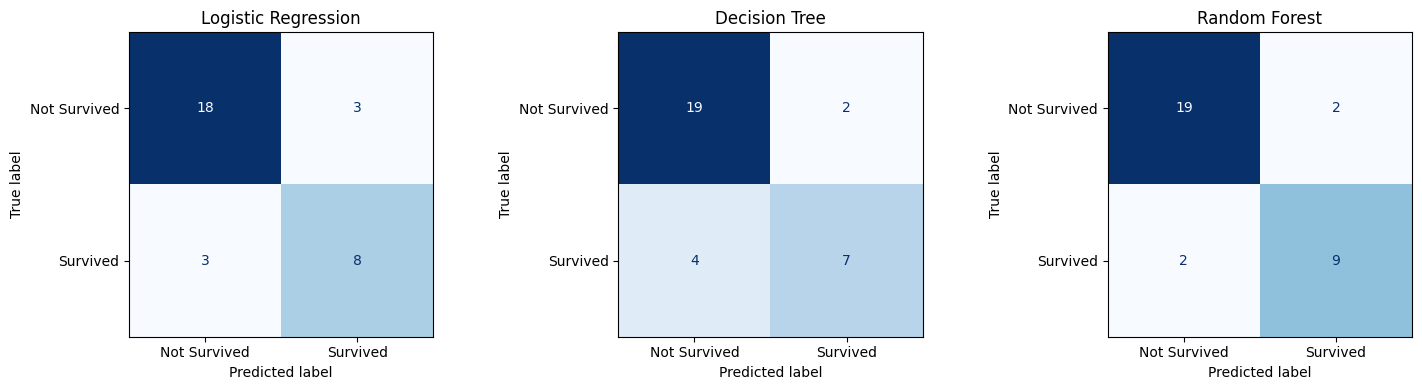

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_logistic),
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tree),
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[2], cmap="Blues", colorbar=False)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

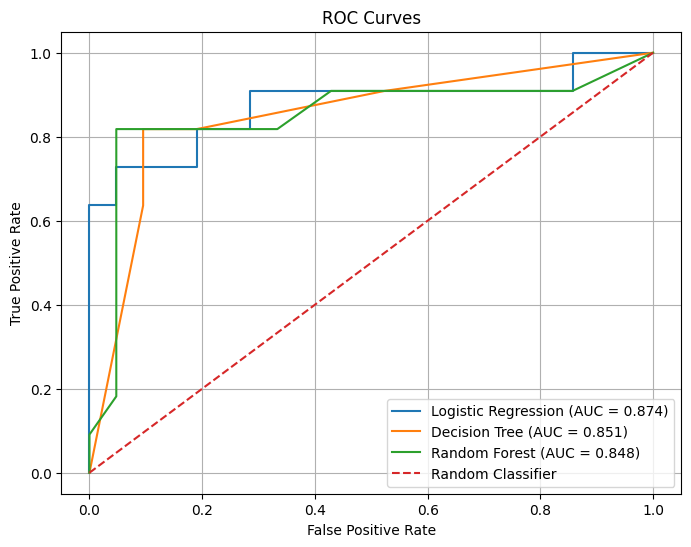

In [52]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_metrics['AUC']:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_metrics['AUC']:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_metrics['AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

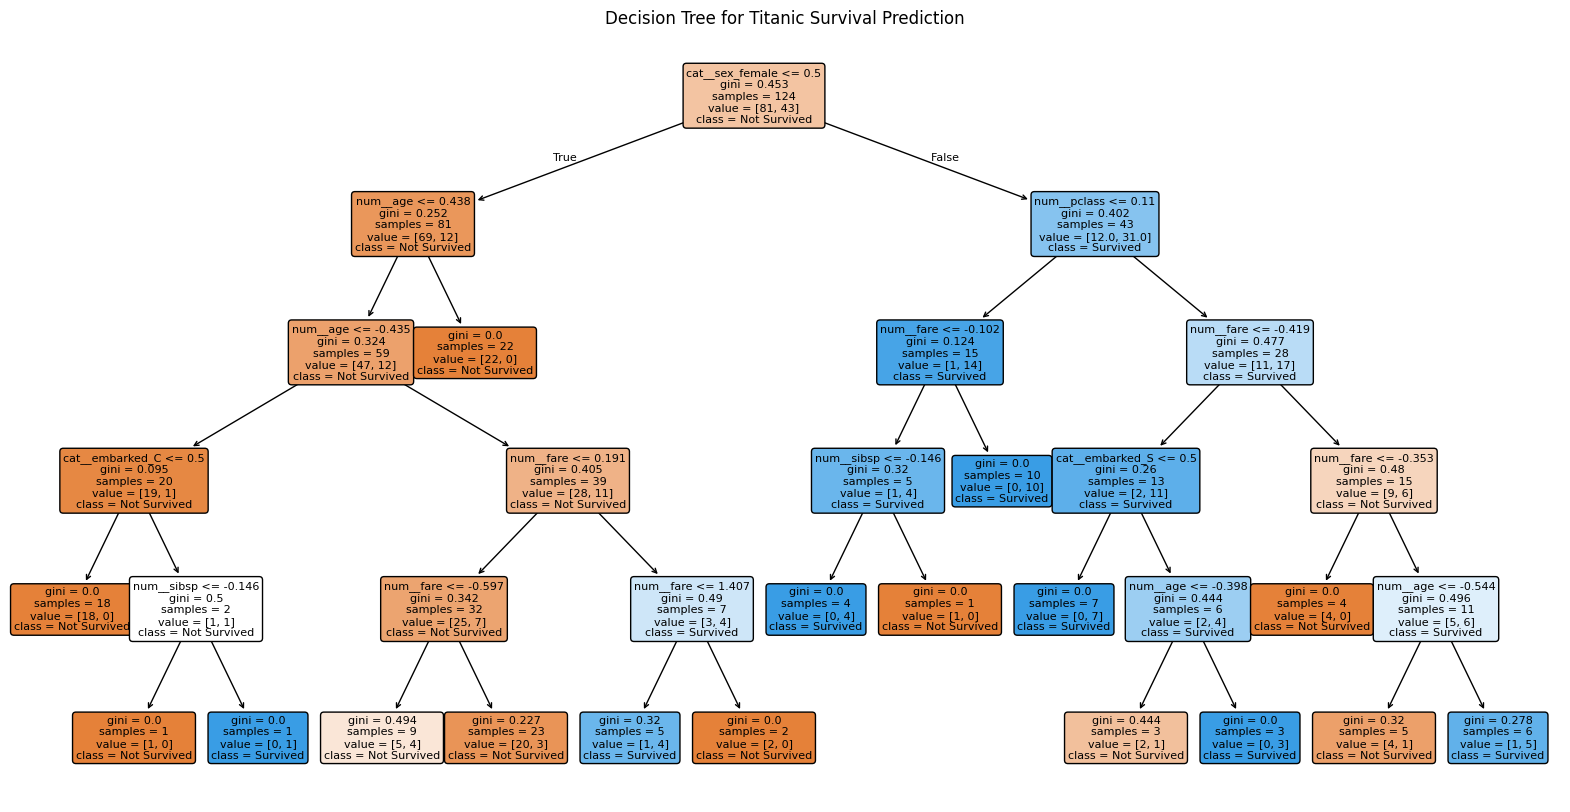

In [53]:
from sklearn.tree import plot_tree

# Get feature names after preprocessing
feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree_pipeline.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()

In [54]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [55]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [56]:
balanced_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)

print("Balanced model trained successfully.")

Balanced model trained successfully.


In [57]:
smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_pipeline.fit(X_train, y_train)

smote_pred = smote_pipeline.predict(X_test)

print("SMOTE model trained successfully.")

SMOTE model trained successfully.


In [58]:
imbalance_results = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, balanced_pred, zero_division=0),
        precision_score(y_test, smote_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, balanced_pred, zero_division=0),
        recall_score(y_test, smote_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, balanced_pred, zero_division=0),
        f1_score(y_test, smote_pred, zero_division=0)
    ]
})

display(imbalance_results.round(3))

,Strategy,Precision,Recall,F1
0,Baseline,0.727,0.727,0.727
1,Class Weight Balanced,0.692,0.818,0.750
2,SMOTE,0.692,0.818,0.750


In [59]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [60]:
rf_for_grid = RandomForestClassifier( random_state=42, oob_score=True )

rf_grid_pipeline = Pipeline(steps=[ ("preprocessor", preprocessor), ("classifier", rf_for_grid) ])

print("Random Forest GridSearch pipeline created.")

Random Forest GridSearch pipeline created.


In [61]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

print("Parameter grid created successfully.")

Parameter grid created successfully.


In [62]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully.")

GridSearchCV completed successfully.


In [63]:
best_rf_pipeline = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 3))

best_rf_model = best_rf_pipeline.named_steps["classifier"]

print("\nOOB Score:")
print(round(best_rf_model.oob_score_, 3))

Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1 Score:
0.71

OOB Score:
0.766


In [64]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked",
    "survived"
]

X_reg = df[regression_features].copy()
y_reg = df["fare"].copy()

print("Regression features:")
print(regression_features)

print("\nTarget:")
print("fare")

Regression features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'survived']

Target:
fare


In [65]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:", X_reg_train.shape)
print("Regression testing shape:", X_reg_test.shape)

Regression training shape: (124, 7)
Regression testing shape: (32, 7)


In [66]:
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "survived"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            reg_numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            reg_categorical_features
        )
    ]
)

print("Regression preprocessing pipeline created.")

Regression preprocessing pipeline created.


In [67]:
from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

print("Linear regression trained successfully.")

Linear regression trained successfully.


In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

# Number of test observations
n = len(y_reg_test)

# Number of predictors after preprocessing
p = len(
    regression_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Regression Metrics")
print("------------------")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
print("Adjusted R²:", round(adjusted_r2, 3))

Regression Metrics
------------------
MAE: 17.011
RMSE: 22.208
R²: 0.348
Adjusted R²: 0.037


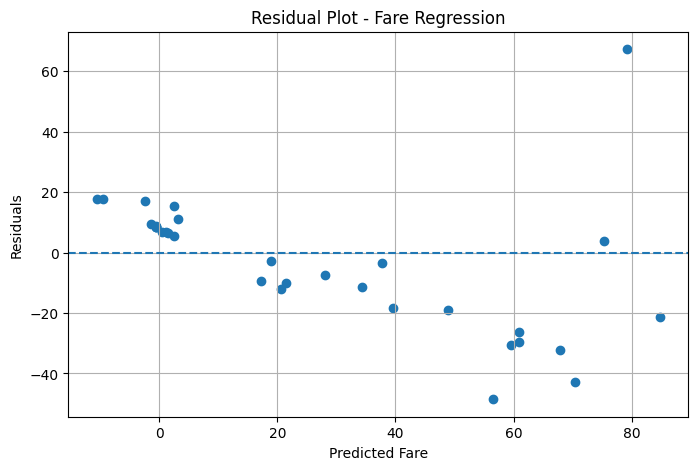

In [69]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_reg_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Fare Regression")

plt.grid()
plt.show()

In [70]:
# Classification comparison
classification_table = comparison_df.round(3)

print("CLASSIFICATION MODEL COMPARISON")
display(classification_table)

# Regression comparison
regression_table = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Value": [mae, rmse, r2, adjusted_r2]
})

print("\nREGRESSION MODEL RESULTS")
display(regression_table.round(3))

CLASSIFICATION MODEL COMPARISON


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.812,0.727,0.727,0.727,0.874
Decision Tree,0.812,0.778,0.636,0.700,0.851
Random Forest,0.875,0.818,0.818,0.818,0.848



REGRESSION MODEL RESULTS


,Metric,Value
0,MAE,17.011
1,RMSE,22.208
2,R²,0.348
3,Adjusted R²,0.037


In [71]:
best_classifier = classification_table["F1"].idxmax()
best_f1 = classification_table.loc[best_classifier, "F1"]
best_auc = classification_table.loc[best_classifier, "AUC"]
best_accuracy = classification_table.loc[best_classifier, "Accuracy"]
best_precision = classification_table.loc[best_classifier, "Precision"]
best_recall = classification_table.loc[best_classifier, "Recall"]

print("Classifier with highest F1:", best_classifier)
print("Accuracy:", round(best_accuracy, 3))
print("Precision:", round(best_precision, 3))
print("Recall:", round(best_recall, 3))
print("F1:", round(best_f1, 3))
print("AUC:", round(best_auc, 3))

Classifier with highest F1: Random Forest
Accuracy: 0.875
Precision: 0.818
Recall: 0.818
F1: 0.818
AUC: 0.848


In [72]:
import joblib

joblib.dump(
    best_rf_pipeline,
    "best_pipeline.joblib"
)

print("Complete pipeline saved as best_pipeline.joblib")

Complete pipeline saved as best_pipeline.joblib


In [73]:
loaded_pipeline = joblib.load("best_pipeline.joblib")

sample_raw = X_test.iloc[[0]]

sample_prediction = loaded_pipeline.predict(sample_raw)

print("Raw input:")
display(sample_raw)

print("Prediction from reloaded pipeline:", sample_prediction)

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked
91,3,male,20.0,0,0,7.8542,S


Prediction from reloaded pipeline: [0]


In [74]:
display(imbalance_results.round(3))

,Strategy,Precision,Recall,F1
0,Baseline,0.727,0.727,0.727
1,Class Weight Balanced,0.692,0.818,0.750
2,SMOTE,0.692,0.818,0.750


In [75]:
print("===== PART B COMPLETION CHECK =====")

print("1. Stratified train/test split: DONE")
print("2. Train-only preprocessing pipeline: DONE")
print("3. Logistic Regression: DONE")
print("4. Decision Tree: DONE")
print("5. Random Forest: DONE")
print("6. Accuracy, Precision, Recall, F1, AUC: DONE")
print("7. Confusion matrices: DONE")
print("8. ROC curves: DONE")
print("9. Decision Tree visualization: DONE")
print("10. Baseline vs Balanced vs SMOTE: DONE")
print("11. Random Forest GridSearchCV: DONE")
print("12. OOB score: DONE")
print("13. Linear regression: DONE")
print("14. MAE, RMSE, R², Adjusted R²: DONE")
print("15. Residual plot: DONE")
print("16. Complete pipeline saved: DONE")
print("17. Saved pipeline reloaded and tested: DONE")

print("\nPart B technical implementation completed.")

===== PART B COMPLETION CHECK =====
1. Stratified train/test split: DONE
2. Train-only preprocessing pipeline: DONE
3. Logistic Regression: DONE
4. Decision Tree: DONE
5. Random Forest: DONE
6. Accuracy, Precision, Recall, F1, AUC: DONE
7. Confusion matrices: DONE
8. ROC curves: DONE
9. Decision Tree visualization: DONE
10. Baseline vs Balanced vs SMOTE: DONE
11. Random Forest GridSearchCV: DONE
12. OOB score: DONE
13. Linear regression: DONE
14. MAE, RMSE, R², Adjusted R²: DONE
15. Residual plot: DONE
16. Complete pipeline saved: DONE
17. Saved pipeline reloaded and tested: DONE

Part B technical implementation completed.


In [76]:
import os

print("Current folder:", os.getcwd())

print("\nIs best_pipeline.joblib present?")
print(os.path.exists("best_pipeline.joblib"))

print("\nFiles:")
print(os.listdir())

Current folder: /content

Is best_pipeline.joblib present?
True

Files:
['.config', 'titanic.csv', 'best_pipeline.joblib', 'sample_data']


In [77]:
import joblib
import os

joblib.dump(best_rf_pipeline, "/content/best_pipeline.joblib")

print("File created:", os.path.exists("/content/best_pipeline.joblib"))
print("File location: /content/best_pipeline.joblib")

File created: True
File location: /content/best_pipeline.joblib
